# 4. Model Development

## Pre-processing

In [1]:
# Libraries imported for this notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# Read EDA_Data.xlsx into a dataframe, formatted dates, and indexed dates.

df = pd.read_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/Pre_Process_Train.xlsx', parse_dates=True, index_col=[0])

In [3]:
# Defined X, the target variable (SVI) and y, the features (treatment plant metrics).

X = df.drop(columns=['Sludge Volume Index'])
y = df['Sludge Volume Index']

A model capable of making predictions from time series data was essential for this project. I chose to explore linear regression, random forest, and ARIMA models.

In [4]:
# Defined number of splits for time series cross-validation.

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

I used TimeSeriesSplit as a cross-validator because it is specifically designed for time series data. The dataset is split into consecutive folds, where each fold is a superset of the previous one, ensuring that the model is trained on data that retains the temporal nature of time series data. In addition, these methods can also check for autocorrelation.

## Linear Regression

In [5]:
# Initialized lists to store MSE scores and predictions.

lr_mse_scores = []
lr_predictions = []
lr_r2_scores = []

In [6]:
# Performed cross-validation and calculated mean squared error for each fold.

# Looped over each fold for cross-validation
for train_index, test_index in tscv.split(X):
    # Split data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # Instantiate linear regression model
    lr_model = LinearRegression()
    # Fit model
    lr_model.fit(X_train, y_train)
    # Make predictions
    lr_pred = lr_model.predict(X_test)
    # Store predictions
    lr_predictions.extend(lr_pred)
    # Calculate MSE
    lr_mse_scores.append(mean_squared_error(y_test, lr_pred))
    # Calculate R^2
    lr_r2_scores.append(r2_score(y_test, lr_pred))

In [7]:
# Calculated average MSE.

lr_avg_mse = np.mean(lr_mse_scores)

In [8]:
# Calculated coefficient of determination.

lr_avg_r2 = np.mean(lr_r2_scores)

## Random Forest

In [9]:
# Initialized lists to store MSE scores and predictions.

rf_mse_scores = []
rf_predictions = []
rf_r2_scores = []

In [10]:
# Performed cross-validation and calculated mean squared error for each fold.

# Looped over each fold for cross-validation
for train_index, test_index in tscv.split(X):
    # Split data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # Instantiate random forest model
    rf_model = RandomForestRegressor()
    # Fit model
    rf_model.fit(X_train, y_train)
    # Make predictions
    rf_pred = rf_model.predict(X_test)
    # Store predictions
    rf_predictions.extend(rf_pred)
    # Calculate MSE
    rf_mse_scores.append(mean_squared_error(y_test, rf_pred))
    # Calculate R^2
    rf_r2_scores.append(r2_score(y_test, rf_pred))

In [11]:
# Calculated average MSE.

rf_avg_mse = np.mean(rf_mse_scores)

In [12]:
# Calculated coefficient of determination.

rf_avg_r2 = np.mean(rf_r2_scores)

## ARIMA

In [13]:
# Initialized lists to store MSE scores and predictions.

arima_mse_scores = []
arima_predictions = []
arima_r2_scores = []

In [14]:
# Performed cross-validation and calculated mean squared error for each fold.

# Looped over each fold for cross-validation
for train_index, test_index in tscv.split(y):
    # Split data
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # Instantiate ARIMA model with frequency set to daily
    arima_model = ARIMA(y_train, order=(5, 1, 0), freq='D')
    # Fit model
    arima_fit = arima_model.fit()
    # Make predictions
    arima_pred = arima_fit.forecast(steps=len(y_test))
    # Store predictions
    arima_predictions.extend(arima_pred)
    # Calculate MSE
    arima_mse_scores.append(mean_squared_error(y_test, arima_pred))
    # Calculate R^2
    arima_r2_scores.append(r2_score(y_test, arima_pred))

/Users/NJahns/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/NJahns/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/NJahns/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/NJahns/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/NJahns/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provi

In [15]:
# Calculated average MSE.

arima_avg_mse = np.mean(arima_mse_scores)

In [16]:
# Calculated coefficient of determination.

arima_avg_r2 = np.mean(arima_r2_scores)

## Model performance

In [19]:
# Compared model MSE scores.

print(f"Linear Regression Average MSE: {lr_avg_mse}, Average R^2: {lr_avg_r2}")

Linear Regression Average MSE: 1.0475924660668652e-21, Average R^2: 1.0


The average MSE for the linear regression model indicates that the model's predictions are very close to the actual values. Essentially, the linear regression model is performing very well on the dataset, with almost no error. The coefficient of determination indicates  that the Linear Regression model perfectly fits the data, capturing all the variability in SVI using the provided features. In other words, the model explains 100% of the variance in the target variable, which is an ideal scenario and implies an excellent model fit.

In [20]:
print(f"Random Forest Average MSE: {rf_avg_mse}, Average R^2: {rf_avg_r2}")

Random Forest Average MSE: 31.971798785191584, Average R^2: 0.7969470581485486


Considering that the mean SVI value in the data is 101 with a max of 235, the random forest model MSE indicates a low level of error in the predictions.The coefficient of determination indicates that the Random Forest model explains about 80% of the variance in the target variable, while the remaining 20% of the variance is unexplained and could be due to factors not accounted for in the model or random variability. In addition, the R^2 value is relatively high, indicating a good fit of the model to the data and a strong ability to explain the variability in SVI using the provided features.

In [21]:
print(f"ARIMA Average MSE: {arima_avg_mse}, Average R^2: {arima_avg_r2}")

ARIMA Average MSE: 372.75732184744174, Average R^2: -1.0710022613398062


The MSE for the ARIMA model indicates poor performance. In combination with the negative R^2 value, these scores indicate that the ARIMA model does not provide a good fit to the data and performs worse than a simple mean prediction model.

In [26]:
# Defined function to plot actual vs predicted values.

def plot_actual_vs_predicted(actual, predicted, model_name):
    plt.figure(figsize=(10, 6))
    plt.plot(actual.index, actual.values, label='Actual', color='blue')
    plt.plot(actual.index, predicted, label='Predicted', color='red')
    plt.title(f'Actual vs Predicted (Model: {model_name})')
    plt.xlabel('Date')
    plt.ylabel('Sludge Volume Index')
    plt.legend()
    plt.show()

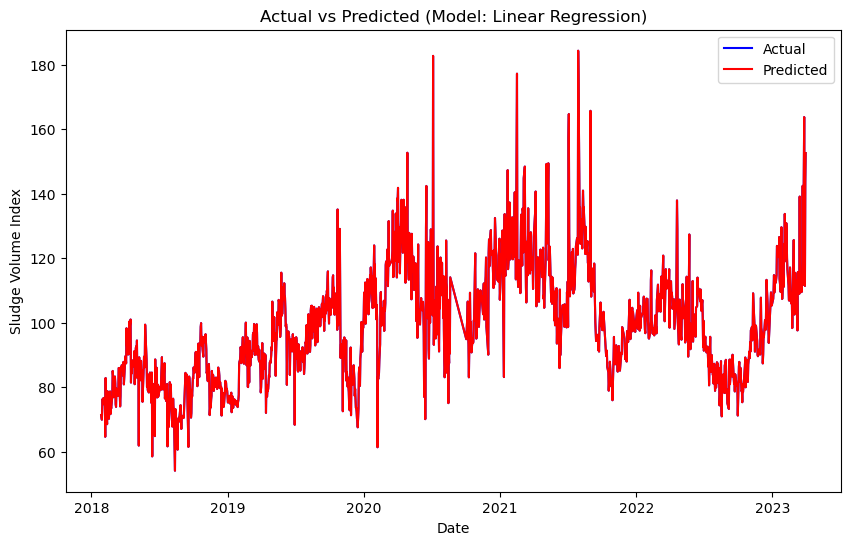

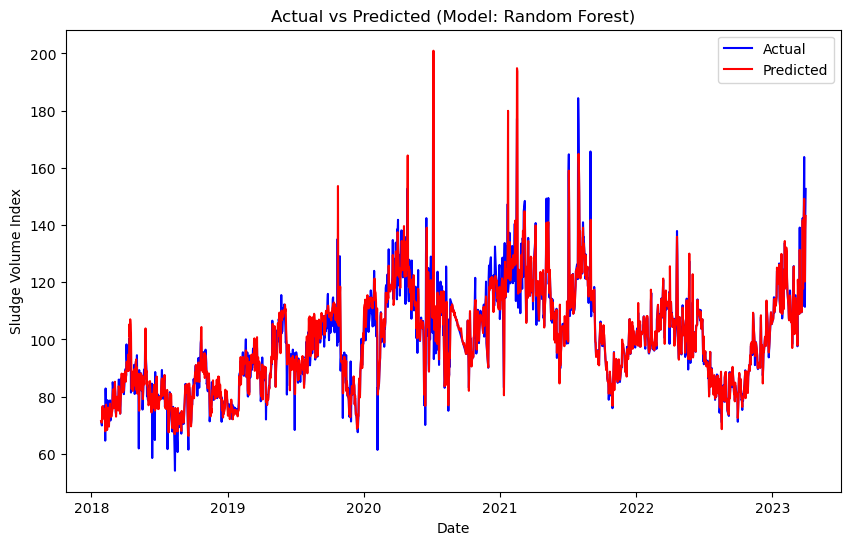

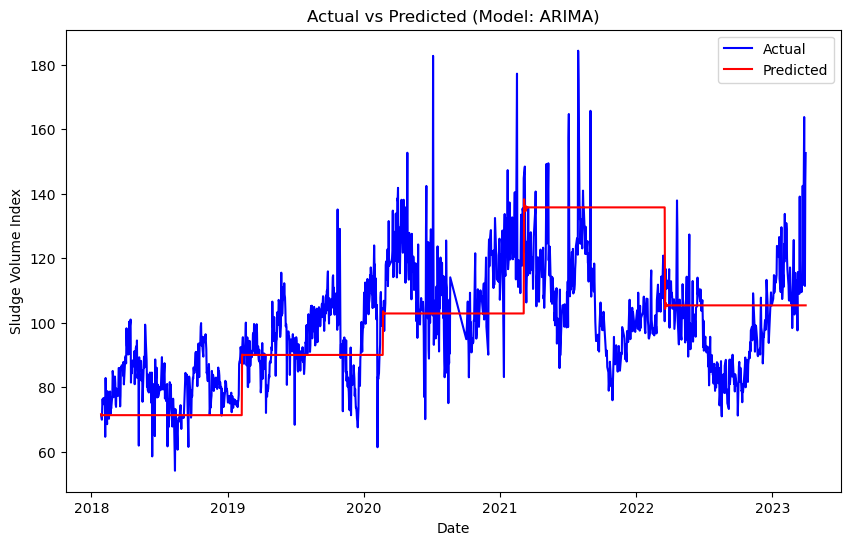

In [28]:
# Plotted actual vs predicted values for each model.

plot_actual_vs_predicted(y.iloc[len(y) - len(lr_predictions):], lr_predictions, "Linear Regression")
plot_actual_vs_predicted(y.iloc[len(y) - len(rf_predictions):], rf_predictions, "Random Forest")
plot_actual_vs_predicted(y.iloc[len(y) - len(arima_predictions):], arima_predictions, "ARIMA")

Actual and predicted values appear to be identical for the linear regressioin model, moderateley similar for the random forest model, and not at all similar for the ARIMA model.

Overall, the linear regression model is the best predictive model for this project.

## Feature importances

In [34]:
# Identified the top 10 features with the highest importance.

# Got the feature names
feature_names = X_train.columns

# Created a dictionary mapping feature names to coefficients
feature_coef = dict(zip(feature_names, lr_model.coef_))

# Sorted the dictionary by coefficient values in descending order
sorted_feature_coef = dict(sorted(feature_coef.items(), key=lambda item: abs(item[1]), reverse=True))

# Print the top 10 features along with their coefficients
print("Top 10 Features and Their Coefficients:")
for i, (feature, coef) in enumerate(sorted_feature_coef.items()):
    if i >= 10:
        break
    print(f"{feature}: {coef}")

Top 10 Features and Their Coefficients:
1st_Sludge Volume Index: 0.7031729765380066
Sludge Volume Index_lag_1: 0.666026063516911
1st_Sludge Volume Index_lag_1: 0.40639801924133157
2nd_Sludge Volume Index: 0.2968270234622616
Sludge Volume Index_lag_2: 0.2596323187964096
2nd_Sludge Volume Index_lag_1: 0.22440294070367697
1st_Sludge Volume Index_lag_2: 0.1819941642962415
2nd_Sludge Volume Index_lag_2: 0.116750394093375
Sludge Volume Index_lag_3: 0.07763862937592798
1st_Sludge Volume Index_lag_3: 0.06524361375866022


The coefficients indicate that first order differenced Sludge Volume Index values is the most important feature for predicting the current SVI, followed by SVI from the previous day. ALL top 10 most important features are related to SVI indicating that the other features predict very little.

# Data save

In [35]:
# Saved to Excel.
df.to_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/Model_Data.xlsx', index=True)